<a href="https://colab.research.google.com/github/Peeyusj/week_11_wavenet/blob/main/week_11_wavenet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [35]:
!pip install datasets -q

In [36]:
from datasets import load_dataset

ds = load_dataset("swami93/indian-names-1.5M", split="train")
print("Total entries:", len(ds))
print("First 5 entries:")
for i in range(5):
    print(ds[i])

Total entries: 114239
First 5 entries:
{'text': 'name: thiv'}
{'text': 'name: ziyan'}
{'text': 'name: del'}
{'text': 'name: bharathushan'}
{'text': 'name: aranamuthan'}


In [37]:
# Extract just the name from each entry
# Each entry is like "name: thiv" — we split on ": " and take the second part
# .strip() removes any extra spaces at the edges
words = [entry['text'].split(': ')[1].strip() for entry in ds]

print("Total names:", len(words))
print("First 10:", words[:10])
print("Longest name:", max(len(w) for w in words), "characters")
print("Shortest name:", min(len(w) for w in words), "characters")

Total names: 114239
First 10: ['thiv', 'ziyan', 'del', 'bharathushan', 'aranamuthan', 'saptahotre', 'lakshay', 'mangaraj', 'gopitha', 'jeylani']
Longest name: 15 characters
Shortest name: 1 characters


In [38]:
# Join all names into one big string, then get unique characters
all_chars = ''.join(words)
unique_chars = sorted(list(set(all_chars)))
print("Unique characters:", unique_chars)
print("How many:", len(unique_chars))

Unique characters: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
How many: 26


In [39]:
# Build vocabulary: 26 letters + 1 special '.' token = 27 total
stoi = {s:i+1 for i, s in enumerate(unique_chars)}  # a=1, b=2, ... z=26
stoi['.'] = 0  # special start/end token gets index 0
itos = {i:s for s, i in stoi.items()}  # reverse: 0='.', 1='a', ...
vocab_size = len(itos)

print("Vocab size:", vocab_size)
print("stoi['a'] =", stoi['a'])
print("itos[0] =", itos[0])

Vocab size: 27
stoi['a'] = 1
itos[0] = .


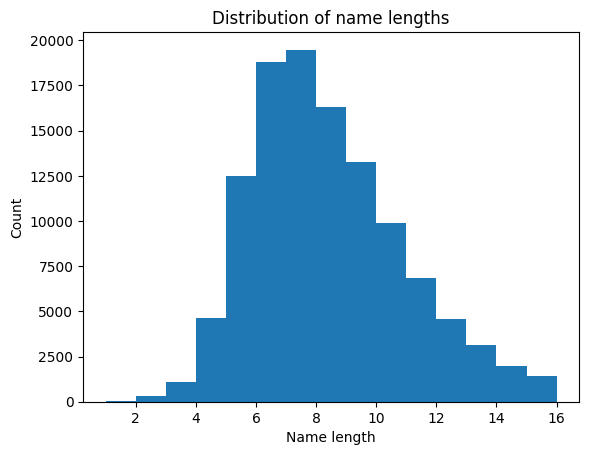

Average length: 7.901460972172376
Names longer than 8 chars: 41105


In [40]:
# Let's see the actual distribution of name lengths
lengths = [len(w) for w in words]
plt.hist(lengths, bins=range(1, max(lengths)+2))
plt.xlabel('Name length')
plt.ylabel('Count')
plt.title('Distribution of name lengths')
plt.show()

# Also print some stats
print("Average length:", sum(lengths) / len(lengths))
print("Names longer than 8 chars:", sum(1 for l in lengths if l > 8))

In [41]:
block_size = 8

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

# Shuffle the names first
import random
random.seed(42)
random.shuffle(words)

# Split: 80% train, 10% validation, 10% test
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([814294, 8]) torch.Size([814294])
torch.Size([101311, 8]) torch.Size([101311])
torch.Size([101289, 8]) torch.Size([101289])


In [42]:
# --- FLAT MLP + BATCHNORM ---
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((vocab_size, n_embd),              generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden),   generator=g) * 0.01
# No b1 anymore! BatchNorm makes bias useless before it (think about why)
bngain = torch.ones(n_hidden)     # NEW: gamma - scale factor
bnbias = torch.zeros(n_hidden)    # NEW: beta - shift factor
W2 = torch.randn((n_hidden, vocab_size),             generator=g) * 0.01
b2 = torch.randn(vocab_size,                         generator=g) * 0.01

# NEW: running stats for inference (we'll discuss this!)
bnmean_running = torch.zeros(n_hidden)
bnvar_running = torch.ones(n_hidden)

parameters = [C, W1, bngain, bnbias, W2, b2]
for p in parameters:
    p.requires_grad = True

print("Total parameters:", sum(p.nelement() for p in parameters))

Total parameters: 22097


In [43]:
max_steps = 50000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)       # flatten embeddings
    hpreact = embcat @ W1                       # no bias! BatchNorm handles it

    # --- BatchNorm (NEW) ---
    bnmean = hpreact.mean(0, keepdim=True)      # mean across the batch
    bnvar = hpreact.var(0, keepdim=True)         # variance across the batch
    hpreact = (hpreact - bnmean) / torch.sqrt(bnvar + 1e-5)  # normalize
    hpreact = bngain * hpreact + bnbias         # scale and shift

    # --- Update running stats (NEW, not part of gradient) ---
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmean.squeeze()
        bnvar_running = 0.999 * bnvar_running + 0.001 * bnvar.squeeze()

    h = torch.tanh(hpreact)                     # activation
    logits = h @ W2 + b2                        # output
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 25000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/  50000: 3.2987
  10000/  50000: 2.3022
  20000/  50000: 2.0492
  30000/  50000: 2.2055
  40000/  50000: 2.0116


In [46]:
# Evaluate loss using running stats (inference mode)
def eval_loss(X, Y):
    emb = C[X]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1
    # Use RUNNING stats, not batch stats
    hpreact = (hpreact - bnmean_running) / torch.sqrt(bnvar_running + 1e-5)
    hpreact = bngain * hpreact + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    return loss.item()

print(f"Train loss: {eval_loss(Xtr, Ytr):.4f}")
print(f"Val loss:   {eval_loss(Xdev, Ydev):.4f}")

Train loss: 2.0740
Val loss:   2.0902


In [47]:
# Generate names using running stats
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        embcat = emb.view(1, -1)
        hpreact = embcat @ W1
        hpreact = (hpreact - bnmean_running) / torch.sqrt(bnvar_running + 1e-5)
        hpreact = bngain * hpreact + bnbias
        h = torch.tanh(hpreact)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

prammel.
ritmolashaye.
parasjini.
anima.
kallania.
thosannel.
maharajan.
muneia.
suraka.
kithrranavari.
avatmah.
mudhooba.
sama.
deeshogarapanaya.
tthivitha.
nakithth.
mamanank.
tema.
shattat.
thysor.


# Model 3: WaveNet with torch.nn

In [48]:
import torch.nn as nn

In [55]:
class FlattenConsecutive(nn.Module):

    def __init__(self, n):
        super().__init__()   # required: tells PyTorch "this is a proper module"
        self.n = n

    def forward(self, x):
        B, T, C = x.shape
        x = x.view(B, T // self.n, C * self.n)
        if x.shape[1] == 1:   # if only 1 group left, remove that dimension
            x = x.squeeze(1)  # (B, 1, C) → (B, C)
        return x

In [56]:
class BatchNorm1d(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.bn = nn.BatchNorm1d(dim)

    def forward(self, x):
        if x.ndim == 2:          # (batch, features) — normal case
            return self.bn(x)
        B, T, C = x.shape        # (batch, groups, features) — 3D case
        x = self.bn(x.view(B * T, C))  # merge batch and groups → (B*T, C)
        return x.view(B, T, C)          # split back → (B, T, C)

In [57]:
n_embd = 24
n_hidden = 128

torch.manual_seed(42)

model = nn.Sequential(
    nn.Embedding(vocab_size, n_embd),

    FlattenConsecutive(2),
    nn.Linear(n_embd * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    nn.Tanh(),

    FlattenConsecutive(2),
    nn.Linear(n_hidden * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    nn.Tanh(),

    FlattenConsecutive(2),
    nn.Linear(n_hidden * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    nn.Tanh(),

    nn.Linear(n_hidden, vocab_size),
)

print("Total parameters:", sum(p.numel() for p in model.parameters()))

Total parameters: 76579


In [61]:
max_steps = 200000
batch_size = 32
lossi = []

optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
model.train()

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    optimizer.zero_grad()
    loss.backward()

    if i == 150000:
        optimizer.param_groups[0]['lr'] = 0.01
    optimizer.step()

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 2.5482
  10000/ 200000: 2.2815
  20000/ 200000: 2.2259
  30000/ 200000: 1.9533
  40000/ 200000: 2.3718
  50000/ 200000: 2.3119
  60000/ 200000: 2.1094
  70000/ 200000: 2.0492
  80000/ 200000: 1.9736
  90000/ 200000: 2.4532
 100000/ 200000: 2.2517
 110000/ 200000: 2.2712
 120000/ 200000: 2.1955
 130000/ 200000: 2.3297
 140000/ 200000: 2.3131
 150000/ 200000: 1.8876
 160000/ 200000: 1.7979
 170000/ 200000: 1.5349
 180000/ 200000: 1.9107
 190000/ 200000: 2.0823


In [62]:
model.eval()  # switches BatchNorm to use running stats

with torch.no_grad():
    logits = model(Xtr)
    train_loss = F.cross_entropy(logits, Ytr)
    logits = model(Xdev)
    val_loss = F.cross_entropy(logits, Ydev)

print(f"Train loss: {train_loss.item():.4f}")
print(f"Val loss:   {val_loss.item():.4f}")

Train loss: 1.9308
Val loss:   1.9766


In [63]:
model.eval()

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

nityasha.
tayom.
thalien.
murugeshraye.
hamdarshita.
mathushina.
indirali.
shaukvin.
ritu.
shooranjith.
rajna.
jaiagha.
souraputtan.
vishnuka.
vaisulla.
pavoeshan.
xyamalini.
kylar.
mangalala.
peranna.
